# Corn Leaf Disease Classification: CRISP-DM Plan

This notebook documents the project from business understanding through data preparation. The task is multiclass image classification with four classes: **Blight**, **Common_Rust**, **Gray_Leaf_Spot**, and **Healthy**.

Project Overview
This project develops a deep-learning image classifier for detecting corn leaf conditions: Blight, Common Rust, Gray Leaf Spot, and Healthy. Following CRISP-DM, the images are cleaned, converted to RGB, resized , and split into training and validation sets. A baseline CNN is compared with a pretrained model such as MobileNetV2 or EfficientNetB0. Performance is measured using accuracy, macro F1-score, per-class recall, precision, and a confusion matrix. The final system is designed to support farmers and agronomists with fast preliminary disease screening, while expert confirmation remains necessary.



## 1. Business Understanding

### Business problem
Corn diseases can reduce yield and quality when they are detected late. Field diagnosis may be slow, inconsistent, or dependent on access to an experienced agronomist. A computer-vision classifier can provide an early screening signal from a photograph of a corn leaf.

### Problem statement
Develop and evaluate an image-classification model that predicts the visible condition of a corn leaf as Blight, Common Rust, Gray Leaf Spot, or Healthy. The model should support rapid, repeatable screening while clearly communicating that predictions are decision support rather than a replacement for expert confirmation.

### Objectives

| Objective | Description | Deliverable |
|---|---|---|
| Classify leaf images | Predict one of four disease/health classes | Trained multiclass classifier |
| Reduce missed disease | Prioritize recall for disease classes, especially in field screening | Per-class recall and confusion matrix |
| Produce trustworthy probabilities | Return confidence scores and flag uncertain cases | Calibrated probabilities or an uncertainty threshold |
| Make the workflow reproducible | Use a documented local path, fixed seed, split, and preprocessing pipeline | Re-runnable notebook |
| Support practical use | Keep inference fast enough for an image-upload workflow | Inference-time and model-size measurements |

### Stakeholders and their interests

| Stakeholder | Interest | What success means for them |
|---|---|---|
| Farmers and field scouts | Fast, accessible disease screening | Correct early alerts and few missed diseased leaves |
| Agronomists and extension officers | A consistent second opinion | Useful explanations, confidence scores, and easy review of uncertain images |
| Agribusiness and crop advisors | Scalable crop-health monitoring | Lower inspection cost and reliable performance across farms |
| Researchers and students | Reproducible experimentation | Transparent data splits, methods, metrics, and limitations |
| Product or deployment team | Maintainable local or web inference | Stable preprocessing, acceptable latency, and versioned models |
| Crop policy and food-security planners | Early visibility of disease patterns | Aggregated, reliable signals without overstating model certainty |

### Value of automation

Automation enables rapid screening of many images, consistent application of the same decision rule, lower manual inspection effort, and earlier escalation to an expert. It is most valuable as a triage layer: high-confidence cases can be prioritized while low-confidence or unusual images are referred for human diagnosis.

### Measures of success

| Success criterion | Target or decision rule |
|---|---|
| Primary model metric | Macro F1 is the main comparison metric because the classes are imbalanced |
| Disease safety | Report recall for each disease class; set a minimum acceptable recall before deployment |
| Healthy/disease confusion | Inspect the confusion matrix and control false negatives for diseased leaves |
| Generalization | Validation performance should remain stable across repeated seeds or a held-out test set |
| Operational usefulness | Measure inference latency, model size, and performance on realistic phone or field images |
| Responsible use | Display confidence and an ``uncertain`` threshold; do not claim expert-level diagnosis without external validation |


## 2. Data Understanding

### Dataset profile and working assumptions

The source dataset is  at `corn_pathology_ai-main/corn_pathology_ai-main/data`, with one folder per class. The audit cell below discovers the path, counts supported image files, checks image dimensions and channels, and creates a reproducible stratified 80/20 split at the file-list level.

| Item | Project value / assumption |
|---|---|
| Class names | Blight, Common_Rust, Gray_Leaf_Spot, Healthy |
| Original image dimensions | Audited from the files; images may have different dimensions |
| Resized dimensions | 224 x 224 pixels, RGB, for a practical transfer-learning baseline |
| Class balance | Imbalanced; Gray_Leaf_Spot is the smallest class |
| Training split | 80% of images, stratified by class |
| Validation split | 20% of images, stratified by class |
| Total source images | 4,188 in the current local dataset audit |
| Expected training images | Computed by the audit cell, approximately 3,350 |
| Expected validation images | Computed by the audit cell, approximately 838 |
| Label type | Single-label multiclass classification |
| Leakage control | Split by image before augmentation; do not place near-duplicate images in both splits |

### Per-class source and training counts

The generated tables distinguish the **source folder count** from the **derived training count**. The current repository has one class-folder dataset rather than pre-created `train` and `validation` folders, so the training counts are created by the stratified split.


In [59]:
from pathlib import Path
from PIL import Image
from sklearn.model_selection import train_test_split

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
RANDOM_STATE = 42
VALIDATION_SIZE = 0.20
TARGET_SIZE = (224, 224)

# Locate the repository data folder from the notebook working directory.
DATA_CANDIDATES = [
    Path.cwd() / "corn_pathology_ai-main" / "corn_pathology_ai-main" / "data",
    Path.cwd() / "data",
]
DATA_DIR = next((path for path in DATA_CANDIDATES if path.exists()), None)
if DATA_DIR is None:
    raise FileNotFoundError(
        "Dataset folder not found. Expected corn_pathology_ai-main/corn_pathology_ai-main/data."
    )

records = []
for class_dir in sorted(path for path in DATA_DIR.iterdir() if path.is_dir()):
    for image_path in sorted(class_dir.iterdir()):
        if image_path.suffix.lower() not in IMAGE_EXTENSIONS:
            continue
        try:
            with Image.open(image_path) as image:
                width, height = image.size
                channels = len(image.getbands())
            records.append({
                "path": str(image_path),
                "class_name": class_dir.name,
                "width": width,
                "height": height,
                "channels": channels,
            })
        except (OSError, ValueError):
            print(f"Skipped unreadable image: {image_path}")

audit_df = pd.DataFrame(records)
if audit_df.empty:
    raise ValueError(f"No supported images found under {DATA_DIR}")

train_df, validation_df = train_test_split(
    audit_df,
    test_size=VALIDATION_SIZE,
    random_state=RANDOM_STATE,
    stratify=audit_df["class_name"],
)

class_names = sorted(audit_df["class_name"].unique())
source_counts = audit_df["class_name"].value_counts().reindex(class_names)
train_counts = train_df["class_name"].value_counts().reindex(class_names)
validation_counts = validation_df["class_name"].value_counts().reindex(class_names)

class_balance_df = pd.DataFrame({
    "class_name": class_names,
    "source_images": source_counts.values,
    "training_images": train_counts.values,
    "validation_images": validation_counts.values,
})
class_balance_df["source_percent"] = (
    class_balance_df["source_images"] / len(audit_df) * 100
).round(2)

print(f"Dataset directory: {DATA_DIR}")
print(f"Total images: {len(audit_df):,}")
print(f"Training images: {len(train_df):,}")
print(f"Validation images: {len(validation_df):,}")
print(f"Original dimensions: {audit_df['width'].nunique()} widths x {audit_df['height'].nunique()} heights")
#print(f"Channels found: {sorted(audit_df['channels'].unique())}")
print("\nPer-class source, training, and validation counts:")
display(class_balance_df)

print("Original dimension summary:")
display(audit_df[["width", "height", "channels"]].describe().round(2))


Dataset directory: c:\Users\admin\Downloads\Capstone Project\corn_pathology_ai-main\corn_pathology_ai-main\data
Total images: 4,188
Training images: 3,350
Validation images: 838
Original dimensions: 172 widths x 208 heights

Per-class source, training, and validation counts:


,class_name,source_images,training_images,validation_images,source_percent
0,Blight,1146,917,229,27.36
1,Common_Rust,1306,1045,261,31.18
2,Gray_Leaf_Spot,574,459,115,13.71
3,Healthy,1162,929,233,27.75


Original dimension summary:


,width,height,channels
count,4188.00,4188.00,4188.00
mean,307.54,297.91,3.00
std,285.72,253.14,0.03
min,180.00,116.00,3.00
25%,256.00,256.00,3.00
50%,256.00,256.00,3.00
75%,256.00,256.00,3.00
max,5184.00,5184.00,4.00


## 3. Data Preparation

### Preparation steps, status, and justification

| Step | Status | Implementation | Justification |
|---|---|---|---|
| Image resizing | Ready | Resize every image to 224 x 224 | Required by the transfer-learning baseline and makes tensor shapes consistent |
| Color conversion | Ready | Convert RGBA/grayscale inputs to RGB | Prevents channel mismatches and standardizes model input |
| Normalisation | Ready to apply | Scale pixel values from 0-255 to 0-1 | Improves numerical stability; use the pretrained model's required preprocessing when applicable |
| Train-validation split | Complete | Stratified 80/20 split, seed 42 | Preserves class proportions and makes results reproducible |
| Batch creation | Ready to apply | Batch size 32 with prefetch | Improves training throughput while keeping memory use manageable |
| Data augmentation | Ready to apply | Training-only horizontal flip, small rotation, zoom, and contrast variation | Improves robustness to camera angle, framing, and lighting without changing labels |
| Leakage check | Required before modeling | Keep near-duplicates and images from the same physical leaf in one split | Prevents inflated validation performance |
| Quality check | Complete for file readability | PIL audit successfully opened all 4,188 supported images | Removes silent corrupt-file failures during training |

### Bias and risk assessment

| Risk | Why it matters | Mitigation |
|---|---|---|
| Class imbalance | Gray Leaf Spot has substantially fewer examples than the other classes | Use macro F1, per-class recall, class weights or balanced sampling, and targeted augmentation |
| Source or collection bias | Images may come from limited farms, cultivars, cameras, backgrounds, or lighting conditions | Test on a geographically and visually separate holdout set |
| Label bias | Labels may reflect annotator judgment or visible symptoms only | Review ambiguous samples with an agronomist and record label provenance |
| Background shortcuts | The model may learn soil, hand, or background cues instead of leaf symptoms | Crop leaves where possible, inspect saliency/error examples, and diversify backgrounds |
| Duplicate leakage | Near-identical images across splits can make validation look unrealistically strong | Deduplicate by file hash or perceptual similarity before the final split |
| Healthy-class bias | A healthy class may be easier to recognize than early disease | Report disease-only recall and evaluate early/weak symptoms separately |

### Possible preprocessing challenges

- Images have heterogeneous dimensions, and a few files contain an alpha channel.
- Resizing can distort leaf shape; center cropping may remove symptoms, so resize with care and compare with aspect-ratio-preserving padding.
- Strong augmentation can erase or alter disease lesions. Use small, biologically plausible transformations.
- Pretrained networks may require a model-specific preprocessing function rather than simple 0-1 scaling.
- Images captured in the field may contain blur, glare, shadows, occlusion, or multiple leaves.

### Expected modeling difficulties

The most likely difficulties are confusing visually similar disease symptoms, recognizing early-stage disease, generalizing beyond the source collection, and separating disease cues from background or acquisition artifacts. Transfer learning with a pretrained CNN is a sensible baseline; compare it against a simpler model and use class-aware error analysis before deployment.

### Metric of success

Use **macro F1** as the headline metric, because it gives each class equal importance despite imbalance. Always report per-class precision, recall, F1, balanced accuracy, the confusion matrix, and one-vs-rest ROC-AUC where probability outputs are reliable. For a field-screening workflow, disease-class recall and the false-negative rate are safety-critical, while confidence thresholding can route uncertain predictions to an agronomist.


Loading the Dataset

In [72]:
#Step 1 — Import the libraries
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report,f1_score
import os
import shutil
import hashlib
from pathlib import Path
from collections import Counter
from PIL import Image
from IPython.display import display
import tensorflow as tf
from tensorflow import keras
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras import layers


1- DATA UNDERSTANDING

In [19]:
DATA_DIR = Path(
    r"C:\Users\admin\Downloads\Capstone Project"
    r"\corn_pathology_ai-main\corn_pathology_ai-main\data"
)

CLASS_NAMES = ["Blight", "Common_Rust", "Gray_Leaf_Spot", "Healthy"]
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

if not DATA_DIR.is_dir():
    raise FileNotFoundError(f"Dataset folder not found: {DATA_DIR}")

print("Dataset folder found:")
print(DATA_DIR)

Dataset folder found:
C:\Users\admin\Downloads\Capstone Project\corn_pathology_ai-main\corn_pathology_ai-main\data


2 -Check the four class folders and count images

In [20]:
class_counts = {}

for class_name in CLASS_NAMES:
    class_dir = DATA_DIR / class_name

    if not class_dir.is_dir():
        class_counts[class_name] = 0
        print(f"{class_name}: folder is missing")
        continue

    image_count = sum(
        1 for path in class_dir.iterdir()
        if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS
    )

    class_counts[class_name] = image_count
    print(f"{class_name}: {image_count} images")

print("\nTotal images:", sum(class_counts.values()))

Blight: 1146 images
Common_Rust: 1306 images
Gray_Leaf_Spot: 574 images
Healthy: 1162 images

Total images: 4188


3 — Read image metadata and identify unreadable images

In [21]:
records = []
unreadable_images = []

for label_id, class_name in enumerate(CLASS_NAMES):
    class_dir = DATA_DIR / class_name

    if not class_dir.is_dir():
        continue

    for image_path in class_dir.iterdir():
        if not image_path.is_file():
            continue

        if image_path.suffix.lower() not in IMAGE_EXTENSIONS:
            continue

        try:
            # First verify the file is a valid image
            with Image.open(image_path) as image:
                image.verify()

            # Reopen to read image metadata
            with Image.open(image_path) as image:
                records.append({
                    "filepath": str(image_path),
                    "filename": image_path.name,
                    "label": class_name,
                    "label_id": label_id,
                    "width": image.width,
                    "height": image.height,
                    "format": image.format,
                    "color_mode": image.mode
                })

        except Exception:
            unreadable_images.append(str(image_path))

raw_df = pd.DataFrame(records)

print("Valid images:", len(raw_df))
print("Unreadable images:", len(unreadable_images))

Valid images: 4188
Unreadable images: 0


4 — Display the dataset information

In [22]:
print("Images in each class:")
display(raw_df["label"].value_counts().reindex(CLASS_NAMES, fill_value=0))

print("\nImage-size summary:")
display(raw_df[["width", "height"]].describe())

print("\nImage formats:")
display(raw_df["format"].value_counts())

print("\nColor modes:")
display(raw_df["color_mode"].value_counts())

Images in each class:


label
Blight            1146
Common_Rust       1306
Gray_Leaf_Spot     574
Healthy           1162
Name: count, dtype: int64


Image-size summary:


,width,height
count,4188.000000,4188.000000
mean,307.536533,297.906160
std,285.716933,253.138674
min,180.000000,116.000000
25%,256.000000,256.000000
50%,256.000000,256.000000
75%,256.000000,256.000000
max,5184.000000,5184.000000



Image formats:


format
JPEG    4183
PNG        4
MPO        1
Name: count, dtype: int64


Color modes:


color_mode
RGB     4183
RGBA       4
CMYK       1
Name: count, dtype: int64

5 — Check for missing values

In [23]:
missing_values = raw_df.isnull().sum()

print("Missing values in the dataset:")
display(missing_values)

print("Total missing values:", missing_values.sum())

Missing values in the dataset:


filepath      0
filename      0
label         0
label_id      0
width         0
height        0
format        0
color_mode    0
dtype: int64

Total missing values: 0


In [65]:
# Check dimensions of a real image from the audited dataset
sample_path = raw_df["filepath"].iloc[0]

with Image.open(sample_path) as image:
    width, height = image.size

print(f"Sample image: {Path(sample_path).name}")
print(f"Image dimensions: {width} x {height} pixels")

print("\nAll dataset image dimensions:")
display(raw_df[["width", "height"]].describe())


Sample image: Corn_Blight (1).jpeg
Image dimensions: 1000 x 585 pixels

All dataset image dimensions:


,width,height
count,4188.000000,4188.000000
mean,307.536533,297.906160
std,285.716933,253.138674
min,180.000000,116.000000
25%,256.000000,256.000000
50%,256.000000,256.000000
75%,256.000000,256.000000
max,5184.000000,5184.000000


In [63]:
for class_name in CLASS_NAMES:
    sample = raw_df[raw_df["label"] == class_name].iloc[0]

    print(
        f"{class_name}: "
        f"{sample['width']} × {sample['height']} pixels"
    )

Blight: 1000 × 585 pixels
Common_Rust: 185 × 500 pixels
Gray_Leaf_Spot: 525 × 395 pixels
Healthy: 256 × 256 pixels


6 — Visualize class balance

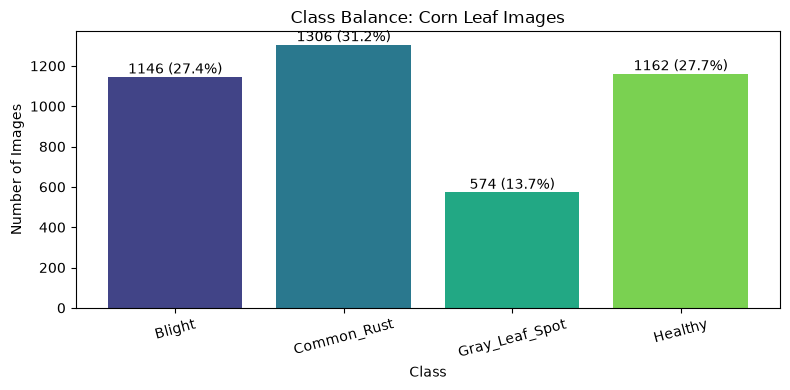

In [24]:
# Step 6 — Visualize class balance
class_balance = raw_df["label"].value_counts().reindex(CLASS_NAMES, fill_value=0)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(class_balance.index, class_balance.values, color=sns.color_palette("viridis", 4))

total_images = class_balance.sum()
for bar, count in zip(bars, class_balance.values):
    percentage = (count / total_images * 100) if total_images else 0
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{count} ({percentage:.1f}%)",
        ha="center", va="bottom"
    )

ax.set_title("Class Balance: Corn Leaf Images")
ax.set_xlabel("Class")
ax.set_ylabel("Number of Images")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

7 — Inspect sample images

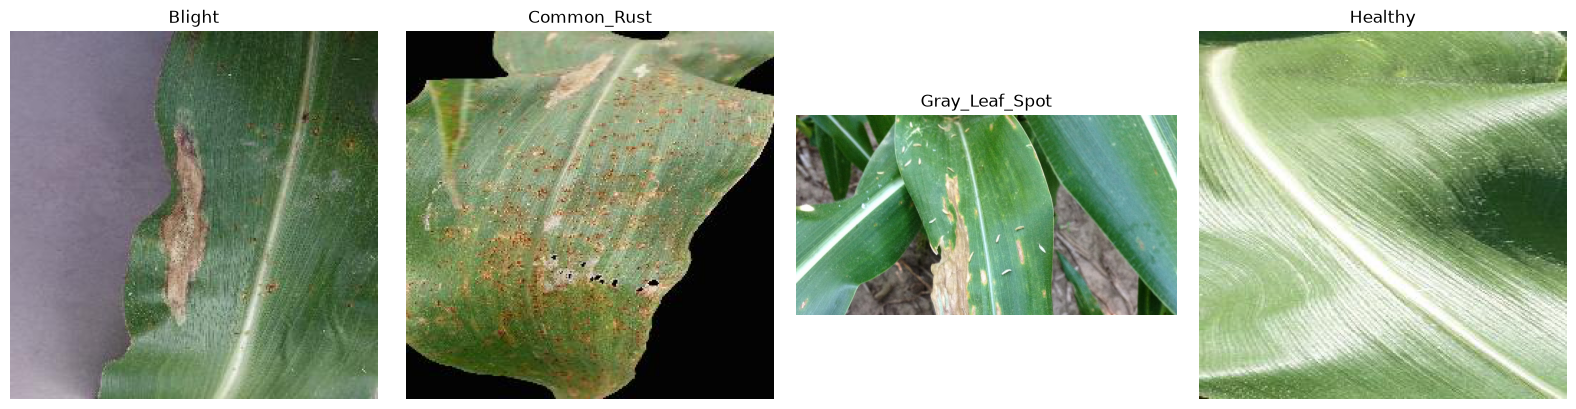

In [35]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for axis, class_name in zip(axes, CLASS_NAMES):
    sample = raw_df[raw_df["label"] == class_name]

    if sample.empty:
        axis.text(0.5, 0.5, f"No images\nin {class_name}",
                  ha="center", va="center")
        axis.set_title(class_name)
        axis.axis("off")
        continue

    image_path = sample.sample(1, random_state=42)["filepath"].iloc[0]

    with Image.open(image_path) as image:
        axis.imshow(image.convert("RGB"))

    axis.set_title(class_name)
    axis.axis("off")

plt.tight_layout()
plt.show()

DATA PREPARATION

8 — Create an exact hash for every valid image

In [36]:
def file_hash(file_path):
    with open(file_path, "rb") as file:
        return hashlib.sha256(file.read()).hexdigest()

raw_df["image_hash"] = raw_df["filepath"].apply(file_hash)

print("Image hashes created.")

Image hashes created.


9 — Find duplicate images with conflicting labels

In [37]:
hash_label_counts = (
    raw_df.groupby("image_hash")["label"]
    .nunique()
)

conflicting_hashes = hash_label_counts[
    hash_label_counts > 1
].index

conflicts_df = raw_df[
    raw_df["image_hash"].isin(conflicting_hashes)
].sort_values("image_hash")

print("Images duplicated with different labels:", len(conflicts_df))

display(conflicts_df[["filepath", "label", "image_hash"]].head(10))

Images duplicated with different labels: 4


,filepath,label,image_hash
891,C:\Users\admin\Downloads\Capstone Project\corn...,Blight,06fdd60f3882e1f9b8c294fa1718dc971836c93cac53ae...
2552,C:\Users\admin\Downloads\Capstone Project\corn...,Gray_Leaf_Spot,06fdd60f3882e1f9b8c294fa1718dc971836c93cac53ae...
119,C:\Users\admin\Downloads\Capstone Project\corn...,Blight,ee3838e2249e671b7b4510b0d3831f30882e2bcbf20c9c...
2968,C:\Users\admin\Downloads\Capstone Project\corn...,Gray_Leaf_Spot,ee3838e2249e671b7b4510b0d3831f30882e2bcbf20c9c...


10 — Remove conflicting and exact duplicate images

In [38]:
clean_df = raw_df[
    ~raw_df["image_hash"].isin(conflicting_hashes)
].drop_duplicates(subset="image_hash", keep="first").copy()

print("Images before cleaning:", len(raw_df))
print("Images after cleaning:", len(clean_df))
print("Duplicates removed:", len(raw_df) - len(clean_df))

print("\nCleaned class distribution:")
display(clean_df["label"].value_counts().reindex(CLASS_NAMES, fill_value=0))

Images before cleaning: 4188
Images after cleaning: 4184
Duplicates removed: 4

Cleaned class distribution:


label
Blight            1144
Common_Rust       1306
Gray_Leaf_Spot     572
Healthy           1162
Name: count, dtype: int64

In [ ]:
#check for color modes and number of rgb images after converting
from PIL import Image

color_mode_records = []

for image_path in clean_df["filepath"]:
    try:
        with Image.open(image_path) as image:
            original_mode = image.mode
            converted_mode = image.convert("RGB").mode

            color_mode_records.append({
                "original_mode": original_mode,
                "converted_mode": converted_mode
            })

    except (OSError, ValueError):
        print(f"Could not read: {image_path}")

color_modes_df = pd.DataFrame(color_mode_records)

print("Original color modes:")
display(color_modes_df["original_mode"].value_counts())

print("\nColor modes after conversion:")
display(color_modes_df["converted_mode"].value_counts())

rgb_count = (color_modes_df["converted_mode"] == "RGB").sum()

print(f"\nImages after cleaning: {len(clean_df)}")
print(f"Number of images converted to RGB: {rgb_count}")

Original color modes:


original_mode
RGB     4179
RGBA       4
CMYK       1
Name: count, dtype: int64


Color modes after conversion:


converted_mode
RGB    4184
Name: count, dtype: int64


Images after cleaning: 4184
Number of images converted to RGB: 4184


In [85]:
import numpy as np
from PIL import Image

pixel_summary = []

for class_name in CLASS_NAMES:
    image_path = clean_df.loc[
        clean_df["label"] == class_name,
        "filepath"
    ].iloc[0]

    with Image.open(image_path) as image:
        pixel_array = np.array(image.convert("RGB"))

    pixel_summary.append({
        "class": class_name,
        "image_file": Path(image_path).name,
        "shape_height_width_channels": pixel_array.shape,
        "min_pixel_value": pixel_array.min(),
        "max_pixel_value": pixel_array.max(),
        "mean_pixel_value": round(pixel_array.mean(), 2)
    })

pixel_summary_df = pd.DataFrame(pixel_summary)
display(pixel_summary_df)

,class,image_file,shape_height_width_channels,min_pixel_value,max_pixel_value,mean_pixel_value
0,Blight,Corn_Blight (1).jpeg,"(585, 1000, 3)",0,255,133.30
1,Common_Rust,Corn_Common_Rust (1).jpg,"(500, 185, 3)",0,255,134.23
2,Gray_Leaf_Spot,Corn_Gray_Spot (1).jpg,"(395, 525, 3)",0,242,54.42
3,Healthy,Corn_Health (1).jpg,"(256, 256, 3)",36,255,138.93


In [86]:
# Learn RGB mean and variance from training images only.
# This prevents validation-data leakage.
pixel_standardizer = layers.Normalization(
    axis=-1,
    name="pixel_standardization"
)

pixel_standardizer.adapt(
    train_ds.map(lambda images, labels: images)
)

print("RGB mean:", pixel_standardizer.mean.numpy().flatten())
print("RGB variance:", pixel_standardizer.variance.numpy().flatten())

RGB mean: [110.569046 127.08725   94.655655]
RGB variance: [2854.4775 3030.293  2840.2236]


11 — Final quality check

In [39]:
final_report = {
    "total_clean_images": len(clean_df),
    "number_of_classes": clean_df["label"].nunique(),
    "missing_values": int(clean_df.isnull().sum().sum()),
    "duplicate_hashes_remaining": int(
        clean_df.duplicated(subset="image_hash").sum()
    ),
    "unreadable_images_found": len(unreadable_images),
    "formats_found": clean_df["format"].value_counts().to_dict(),
    "color_modes_found": clean_df["color_mode"].value_counts().to_dict()
}

for check, result in final_report.items():
    print(f"{check}: {result}")

total_clean_images: 4184
number_of_classes: 4
missing_values: 0
duplicate_hashes_remaining: 0
unreadable_images_found: 0
formats_found: {'JPEG': 4179, 'PNG': 4, 'MPO': 1}
color_modes_found: {'RGB': 4179, 'RGBA': 4, 'CMYK': 1}


12 — Save the cleaned dataset manifest

In [40]:
cleaned_manifest_path = DATA_DIR / "cleaned_image_dataset.csv"

clean_df.to_csv(cleaned_manifest_path, index=False)

print("Cleaned dataset manifest saved to:")
print(cleaned_manifest_path)

Cleaned dataset manifest saved to:
c:\Users\admin\Downloads\Capstone Project\corn_pathology_ai-main\corn_pathology_ai-main\data\cleaned_image_dataset.csv


13 — Check that each of the four classes has images

In [41]:
final_class_counts = clean_df["label"].value_counts().reindex(
    CLASS_NAMES,
    fill_value=0
)

display(final_class_counts)

empty_classes = final_class_counts[final_class_counts == 0]

if len(empty_classes) > 0:
    print("\nThese classes need images before four-class training:")
    print(list(empty_classes.index))
else:
    print("\nDataset is ready for four-class splitting and training.")

label
Blight            1144
Common_Rust       1306
Gray_Leaf_Spot     572
Healthy           1162
Name: count, dtype: int64


Dataset is ready for four-class splitting and training.


14 — Create reproducible training and validation datasets

In [42]:
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42
VALIDATION_SIZE = 0.20

if (final_class_counts == 0).any():
    raise ValueError(
        "Cannot create a four-class split until every class has at least one image."
    )

train_df, validation_df = train_test_split(
    clean_df,
    test_size=VALIDATION_SIZE,
    random_state=RANDOM_STATE,
    stratify=clean_df["label"]
)

print("Training images:", len(train_df))
print("Validation images:", len(validation_df))

split_summary = pd.DataFrame({
    "training_images": train_df["label"].value_counts(),
    "validation_images": validation_df["label"].value_counts()
}).reindex(CLASS_NAMES, fill_value=0)

display(split_summary)

Training images: 3347
Validation images: 837


,training_images,validation_images
label,,
Blight,915,229
Common_Rust,1045,261
Gray_Leaf_Spot,458,114
Healthy,929,233


 15 — Create TensorFlow Training and Validation Datasets

In [45]:
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

def load_and_prepare_image(filepath, label):
    image_bytes = tf.io.read_file(filepath)

    image = tf.io.decode_image(
        image_bytes,
        channels=3,
        expand_animations=False
    )

    image.set_shape([None, None, 3])
    image = tf.image.resize(image, IMAGE_SIZE)
    image = tf.cast(image, tf.float32)

    return image, label

def create_dataset(dataframe, shuffle=False):
    dataset = tf.data.Dataset.from_tensor_slices((
        dataframe["filepath"].values,
        dataframe["label_id"].values
    ))

    dataset = dataset.map(
        load_and_prepare_image,
        num_parallel_calls=AUTOTUNE
    )

    if shuffle:
        dataset = dataset.shuffle(
            buffer_size=len(dataframe),
            seed=RANDOM_STATE
        )

    return dataset.batch(BATCH_SIZE).prefetch(AUTOTUNE)

train_ds = create_dataset(train_df, shuffle=True)
validation_ds = create_dataset(validation_df)

print("Training and validation datasets are ready.")

Training and validation datasets are ready.


In [53]:
from sklearn.utils.class_weight import compute_class_weight

IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

# Ensure labels always follow the CLASS_NAMES order.
label_to_id = {class_name: index for index, class_name in enumerate(CLASS_NAMES)}

train_df = train_df.copy()
validation_df = validation_df.copy()

train_df["label_id"] = train_df["label"].map(label_to_id).astype("int32")
validation_df["label_id"] = validation_df["label"].map(label_to_id).astype("int32")

def load_and_prepare_image(filepath, label):
    image_bytes = tf.io.read_file(filepath)

    image = tf.io.decode_image(
        image_bytes,
        channels=3,
        expand_animations=False
    )

    image.set_shape([None, None, 3])
    image = tf.image.resize(image, IMAGE_SIZE)
    image = tf.cast(image, tf.float32)

    return image, label

def create_dataset(dataframe, shuffle=False):
    dataset = tf.data.Dataset.from_tensor_slices((
        dataframe["filepath"].values,
        dataframe["label_id"].values
    ))

    dataset = dataset.map(
        load_and_prepare_image,
        num_parallel_calls=AUTOTUNE
    )

    if shuffle:
        dataset = dataset.shuffle(
            buffer_size=len(dataframe),
            seed=RANDOM_STATE,
            reshuffle_each_iteration=True
        )

    return dataset.batch(BATCH_SIZE).prefetch(AUTOTUNE)

train_ds = create_dataset(train_df, shuffle=True)
validation_ds = create_dataset(validation_df)

print("Training and validation datasets are ready.")

Training and validation datasets are ready.


2. Calculate class weights

In [55]:
classes = np.arange(len(CLASS_NAMES))

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_df["label_id"]
)

class_weights = dict(enumerate(weights))

display(pd.DataFrame({
    "class": CLASS_NAMES,
    "training_images": train_df["label"].value_counts()
        .reindex(CLASS_NAMES, fill_value=0).values,
    "class_weight": weights.round(3)
}))

,class,training_images,class_weight
0,Blight,915,0.914
1,Common_Rust,1045,0.801
2,Gray_Leaf_Spot,458,1.827
3,Healthy,929,0.901


3. Establish the majority-class reference

In [56]:
majority_class = train_df["label"].mode()[0]
majority_accuracy = (validation_df["label"] == majority_class).mean()

print("Majority class:", majority_class)
print(f"Majority-class baseline accuracy: {majority_accuracy:.3f}")

Majority class: Common_Rust
Majority-class baseline accuracy: 0.312


Build the baseline CNN

In [57]:
tf.keras.utils.set_random_seed(RANDOM_STATE)

baseline_model = keras.Sequential([
    layers.Input(shape=IMAGE_SIZE + (3,)),

    # Converts pixel values from 0–255 to 0–1.
    layers.Rescaling(1 / 255.0),

    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D(),

    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.30),
    layers.Dense(len(CLASS_NAMES), activation="softmax")
], name="baseline_cnn")

baseline_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

baseline_model.summary()

Model: "baseline_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_2 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,764 (366.27 KB)

 Trainable params: 93,764 (366.27 KB)

 Non-trainable params: 0 (0.00 B)

5. Train the baseline CNN with early stopping

In [ ]:
ARTIFACT_DIR = Path.cwd() / "artifacts"
ARTIFACT_DIR.mkdir(exist_ok=True)

baseline_callbacks = [
    keras.callbacks.ModelCheckpoint(
        ARTIFACT_DIR / "best_baseline_cnn.keras",
        monitor="val_loss",
        save_best_only=True
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        min_lr=1e-6
    )
]

baseline_history = baseline_model.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=15,
    class_weight=class_weights,
    callbacks=baseline_callbacks,
    verbose=1
)

6. Create one evaluation function

In [ ]:
def evaluate_model(model, model_name):
    probabilities = model.predict(validation_ds)
    y_true = validation_df["label_id"].to_numpy()
    y_pred = probabilities.argmax(axis=1)

    accuracy = (y_pred == y_true).mean()
    macro_f1 = f1_score(y_true, y_pred, average="macro")

    print(f"{model_name} validation accuracy: {accuracy:.3f}")
    print(f"{model_name} validation macro F1: {macro_f1:.3f}\n")

    print(classification_report(
        y_true,
        y_pred,
        target_names=CLASS_NAMES,
        digits=3
    ))

    fig, ax = plt.subplots(figsize=(7, 6))
    ConfusionMatrixDisplay.from_predictions(
        y_true,
        y_pred,
        display_labels=CLASS_NAMES,
        cmap="Blues",
        xticks_rotation=20,
        ax=ax
    )
    ax.set_title(f"{model_name}: Validation Confusion Matrix")
    plt.tight_layout()
    plt.show()

    return {
        "model": model_name,
        "accuracy": accuracy,
        "macro_f1": macro_f1,
        "y_true": y_true,
        "y_pred": y_pred,
        "probabilities": probabilities
    }

7. Evaluate the baseline CNN

In [ ]:
baseline_results = evaluate_model(
    baseline_model,
    "Baseline CNN"
)

8. Build the MobileNetV2 model

In [ ]:
tf.keras.utils.set_random_seed(RANDOM_STATE)

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.10),
    layers.RandomContrast(0.10),
], name="augmentation")

base_model = keras.applications.MobileNetV2(
    include_top=False,
    weights="imagenet",
    input_shape=IMAGE_SIZE + (3,)
)

# Keep pretrained layers frozen during first training stage.
base_model.trainable = False

inputs = keras.Input(shape=IMAGE_SIZE + (3,), name="image")
x = data_augmentation(inputs)

# MobileNetV2 requires pixels scaled from 0–255 to -1–1.
x = layers.Rescaling(
    scale=1 / 127.5,
    offset=-1,
    name="mobilenet_v2_preprocessing"
)(x)

x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.30)(x)

outputs = layers.Dense(
    len(CLASS_NAMES),
    activation="softmax",
    name="class_probability"
)(x)

mobilenet_model = keras.Model(
    inputs,
    outputs,
    name="corn_leaf_mobilenet_v2"
)

mobilenet_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

mobilenet_model.summary()

9. Train MobileNetV2 with early stopping

In [ ]:
mobilenet_callbacks = [
    keras.callbacks.ModelCheckpoint(
        ARTIFACT_DIR / "best_mobilenet_v2.keras",
        monitor="val_loss",
        save_best_only=True
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        min_lr=1e-6
    )
]

mobilenet_history = mobilenet_model.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=15,
    class_weight=class_weights,
    callbacks=mobilenet_callbacks,
    verbose=1
)

10. Evaluate MobileNetV2

In [ ]:
mobilenet_results = evaluate_model(
    mobilenet_model,
    "MobileNetV2"
)

11. Compare both models

In [ ]:
comparison_df = pd.DataFrame([
    {
        "model": "Majority-class reference",
        "accuracy": majority_accuracy,
        "macro_f1": np.nan
    },
    {
        "model": baseline_results["model"],
        "accuracy": baseline_results["accuracy"],
        "macro_f1": baseline_results["macro_f1"]
    },
    {
        "model": mobilenet_results["model"],
        "accuracy": mobilenet_results["accuracy"],
        "macro_f1": mobilenet_results["macro_f1"]
    }
])

display(comparison_df.sort_values("macro_f1", ascending=False))

12. Plot MobileNetV2 learning curves

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(mobilenet_history.history["loss"], label="Training loss")
axes[0].plot(mobilenet_history.history["val_loss"], label="Validation loss")
axes[0].set_title("MobileNetV2 Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(mobilenet_history.history["accuracy"], label="Training accuracy")
axes[1].plot(mobilenet_history.history["val_accuracy"], label="Validation accuracy")
axes[1].set_title("MobileNetV2 Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()

13. Inspect MobileNetV2 mistakes

In [ ]:
validation_results = validation_df[["filepath", "label"]].copy()

validation_results["predicted_label"] = [
    CLASS_NAMES[index] for index in mobilenet_results["y_pred"]
]

validation_results["confidence"] = (
    mobilenet_results["probabilities"].max(axis=1)
)

errors_df = validation_results[
    validation_results["label"] != validation_results["predicted_label"]
].sort_values("confidence", ascending=False)

print("Misclassified validation images:", len(errors_df))
display(errors_df.head(10))

14. Save the final model

In [ ]:
final_model = mobilenet_model
final_model_path = ARTIFACT_DIR / "corn_leaf_classifier_mobilenet_v2.keras"

final_model.save(final_model_path)

metadata = {
    "class_names": CLASS_NAMES,
    "image_size": IMAGE_SIZE,
    "selected_model": "MobileNetV2",
    "validation_macro_f1": float(mobilenet_results["macro_f1"])
}

with open(
    ARTIFACT_DIR / "model_metadata.json",
    "w",
    encoding="utf-8"
) as file:
    json.dump(metadata, file, indent=2)

print(f"Final model saved to: {final_model_path}")

## 4. Modeling

The workflow below trains a transfer-learning classifier (EfficientNetB0), which is a strong practical baseline for image classification. Run the cells in order. The validation set is used only for model selection and reporting; retain a separate, unseen field-test set for final deployment testing when one becomes available.

## 4. Modeling

### 15 — Establish a simple baseline

In [ ]:
majority_class = train_df["label"].mode()[0]
majority_accuracy = (validation_df["label"] == majority_class).mean()

print("Majority class:", majority_class)
print(f"Majority-class baseline accuracy: {majority_accuracy:.3f}")

### 16 — Build a baseline CNN

In [ ]:
tf.keras.utils.set_random_seed(RANDOM_STATE)

baseline_model = keras.Sequential([
    layers.Input(shape=IMAGE_SIZE + (3,)),

    # Scale pixels from 0–255 to 0–1.
    layers.Rescaling(1 / 255.0),

    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D(),

    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.30),
    layers.Dense(len(CLASS_NAMES), activation="softmax")
], name="baseline_cnn")

baseline_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

baseline_model.summary()

### 17 — Train the baseline CNN with early stopping

In [ ]:
baseline_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        min_lr=1e-6
    ),
]

baseline_history = baseline_model.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=15,
    class_weight=class_weights,
    callbacks=baseline_callbacks
)

### 15 — Validate labels and calculate class weights

Class weights prevent the larger classes from dominating the training loss.

In [46]:
from sklearn.utils.class_weight import compute_class_weight

label_to_id = {class_name: index for index, class_name in enumerate(CLASS_NAMES)}
for dataframe_name, dataframe in {"train_df": train_df, "validation_df": validation_df}.items():
    expected_ids = dataframe["label"].map(label_to_id)
    if not expected_ids.equals(dataframe["label_id"]):
        dataframe["label_id"] = expected_ids.astype("int32")

classes = np.arange(len(CLASS_NAMES))
weights = compute_class_weight(
    class_weight="balanced", classes=classes, y=train_df["label_id"]
)
class_weights = dict(enumerate(weights))

display(pd.DataFrame({
    "class": CLASS_NAMES,
    "training_images": train_df["label"].value_counts().reindex(CLASS_NAMES).values,
    "class_weight": weights.round(3),
}))


,class,training_images,class_weight
0,Blight,915,0.914
1,Common_Rust,1045,0.801
2,Gray_Leaf_Spot,458,1.827
3,Healthy,929,0.901


### 16 — Build the transfer-learning model

Augmentation is active only during training. EfficientNet's pretrained base is initially frozen so the new classification head can learn without destroying useful visual features.

In [47]:
tf.keras.utils.set_random_seed(RANDOM_STATE)

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.10),
    layers.RandomContrast(0.10),
], name="augmentation")

base_model = keras.applications.MobileNetV2(
    include_top=False,
    weights="imagenet",
    input_shape=IMAGE_SIZE + (3,)
)
base_model.trainable = False

inputs = keras.Input(shape=IMAGE_SIZE + (3,), name="image")
x = data_augmentation(inputs)

# MobileNetV2 expects values scaled from 0–255 to -1–1.
x = layers.Rescaling(1 / 127.5, offset=-1, name="mobilenet_preprocessing")(x)

x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.30)(x)
outputs = layers.Dense(
    len(CLASS_NAMES),
    activation="softmax",
    name="class_probability"
)(x)

model = keras.Model(inputs, outputs, name="corn_leaf_mobilenet_v2")

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

model.summary()

Model: "corn_leaf_mobilenet_v2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image (InputLayer)              │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenet_preprocessing         │ (None, 224, 224, 3)    │             0 │
│ (Rescaling)                     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ class_probability (Dense)       │ (None, 4)              │         5,124 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,263,108 (8.63 MB)

 Trainable params: 5,124 (20.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [48]:
tf.keras.utils.set_random_seed(RANDOM_STATE)

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.10),
    layers.RandomContrast(0.10),
], name="augmentation")

base_model = keras.applications.EfficientNetB0(
    include_top=False, weights="imagenet", input_shape=IMAGE_SIZE + (3,)
)
base_model.trainable = False

inputs = keras.Input(shape=IMAGE_SIZE + (3,), name="image")
x = data_augmentation(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.30)(x)
outputs = layers.Dense(len(CLASS_NAMES), activation="softmax", name="class_probability")(x)

model = keras.Model(inputs, outputs, name="corn_leaf_efficientnet")
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"],
)
model.summary()


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 14s 1us/step


Model: "corn_leaf_efficientnet"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image (InputLayer)              │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ class_probability (Dense)       │ (None, 4)              │         5,124 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,054,695 (15.47 MB)

 Trainable params: 5,124 (20.02 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

### 17 — Train the classifier head

Training stops early if validation loss stops improving. The best validation-loss checkpoint is kept in `artifacts/`.

In [49]:
from pathlib import Path

ARTIFACT_DIR = Path.cwd() / "artifacts"
ARTIFACT_DIR.mkdir(exist_ok=True)
checkpoint_path = ARTIFACT_DIR / "best_corn_leaf_model.keras"

callbacks = [
    keras.callbacks.ModelCheckpoint(checkpoint_path, monitor="val_loss", save_best_only=True),
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.2, patience=2, min_lr=1e-6),
]

history_head = model.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=15,
    class_weight=class_weights,
    callbacks=callbacks,
)


Epoch 1/15


c:\Users\admin\anaconda3\envs\machine-learning-task\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


105/105 ━━━━━━━━━━━━━━━━━━━━ 604s 5s/step - accuracy: 0.8183 - loss: 0.5673 - val_accuracy: 0.8984 - val_loss: 0.3140 - learning_rate: 0.0010
Epoch 2/15
105/105 ━━━━━━━━━━━━━━━━━━━━ 503s 4s/step - accuracy: 0.9062 - loss: 0.3089 - val_accuracy: 0.9152 - val_loss: 0.2516 - learning_rate: 0.0010
Epoch 3/15
105/105 ━━━━━━━━━━━━━━━━━━━━ 513s 4s/step - accuracy: 0.9184 - loss: 0.2546 - val_accuracy: 0.9176 - val_loss: 0.2178 - learning_rate: 0.0010
Epoch 4/15
105/105 ━━━━━━━━━━━━━━━━━━━━ 452s 4s/step - accuracy: 0.9256 - loss: 0.2355 - val_accuracy: 0.9259 - val_loss: 0.2045 - learning_rate: 0.0010
Epoch 5/15
105/105 ━━━━━━━━━━━━━━━━━━━━ 282s 2s/step - accuracy: 0.9256 - loss: 0.2318 - val_accuracy: 0.9307 - val_loss: 0.2064 - learning_rate: 0.0010
Epoch 6/15
105/105 ━━━━━━━━━━━━━━━━━━━━ 414s 4s/step - accuracy: 0.9361 - loss: 0.2034 - val_accuracy: 0.9295 - val_loss: 0.1895 - learning_rate: 0.0010
Epoch 7/15
105/105 ━━━━━━━━━━━━━━━━━━━━ 433s 4s/step - accuracy: 0.9349 - loss: 0.1996 - val_

### 18 — Fine-tune the upper EfficientNet layers

This optional second stage uses a much smaller learning rate. Skip it if the first stage overfits or validation metrics get worse.

In [50]:
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"],
)

initial_epoch = len(history_head.history["loss"])
history_fine = model.fit(
    train_ds,
    validation_data=validation_ds,
    initial_epoch=initial_epoch,
    epochs=initial_epoch + 8,
    class_weight=class_weights,
    callbacks=callbacks,
)

model = keras.models.load_model(checkpoint_path)


Epoch 16/23
105/105 ━━━━━━━━━━━━━━━━━━━━ 687s 5s/step - accuracy: 0.8924 - loss: 0.3020 - val_accuracy: 0.9319 - val_loss: 0.1899 - learning_rate: 1.0000e-05
Epoch 17/23
105/105 ━━━━━━━━━━━━━━━━━━━━ 582s 5s/step - accuracy: 0.9113 - loss: 0.2593 - val_accuracy: 0.9283 - val_loss: 0.2012 - learning_rate: 1.0000e-05
Epoch 18/23
105/105 ━━━━━━━━━━━━━━━━━━━━ 518s 5s/step - accuracy: 0.9238 - loss: 0.2374 - val_accuracy: 0.9307 - val_loss: 0.1984 - learning_rate: 1.0000e-05
Epoch 19/23
105/105 ━━━━━━━━━━━━━━━━━━━━ 576s 5s/step - accuracy: 0.9202 - loss: 0.2288 - val_accuracy: 0.9307 - val_loss: 0.1989 - learning_rate: 2.0000e-06
Epoch 20/23
105/105 ━━━━━━━━━━━━━━━━━━━━ 618s 6s/step - accuracy: 0.9292 - loss: 0.2251 - val_accuracy: 0.9307 - val_loss: 0.1986 - learning_rate: 2.0000e-06


## 5. Evaluation

Accuracy alone can hide poor performance on a minority disease. Report macro F1, per-class recall, and the confusion matrix; recall is especially important because missed disease cases are costly.

### 19 — Plot learning curves


In [ ]:
histories = [history_head.history]
if "history_fine" in globals():
    histories.append(history_fine.history)

history = {key: np.concatenate([item[key] for item in histories]) for key in histories[0]}
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for axis, metric, title in zip(axes, ["loss", "accuracy"], ["Loss", "Accuracy"]):
    axis.plot(history[metric], label=f"Training {metric}")
    axis.plot(history[f"val_{metric}"], label=f"Validation {metric}")
    axis.set_title(title)
    axis.set_xlabel("Epoch")
    axis.legend()
plt.tight_layout()
plt.show()


### 20 — Evaluate validation performance and inspect errors


In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, f1_score

probabilities = model.predict(validation_ds)
y_true = validation_df["label_id"].to_numpy()
y_pred = probabilities.argmax(axis=1)

print(f"Validation accuracy: {(y_pred == y_true).mean():.3f}")
print(f"Validation macro F1: {f1_score(y_true, y_pred, average='macro'):.3f}")
print("\nClassification report:")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=3))

fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(
    y_true, y_pred, display_labels=CLASS_NAMES, cmap="Blues", xticks_rotation=20, ax=ax
)
ax.set_title("Validation Confusion Matrix")
plt.tight_layout()
plt.show()

validation_results = validation_df[["filepath", "label"]].copy()
validation_results["predicted_label"] = [CLASS_NAMES[index] for index in y_pred]
validation_results["confidence"] = probabilities.max(axis=1)
errors_df = validation_results.query("label != predicted_label").sort_values("confidence", ascending=False)
print(f"Misclassified validation images: {len(errors_df)}")
display(errors_df.head(10))


## 6. Deployment / Next Steps

Save the best model with its class-order metadata. Before real use, evaluate on an external field dataset, choose a confidence threshold with an agronomist, and monitor performance as new images, cultivars, cameras, and locations are introduced.

In [ ]:
import json

final_model_path = ARTIFACT_DIR / "corn_leaf_classifier.keras"
model.save(final_model_path)

metadata = {
    "class_names": CLASS_NAMES,
    "image_size": IMAGE_SIZE,
    "validation_size": VALIDATION_SIZE,
    "random_state": RANDOM_STATE,
}
with open(ARTIFACT_DIR / "model_metadata.json", "w", encoding="utf-8") as file:
    json.dump(metadata, file, indent=2)

print(f"Model saved to: {final_model_path}")
print(f"Metadata saved to: {ARTIFACT_DIR / 'model_metadata.json'}")
